In [4]:
# Import libraries 

import pandas as pd
import numpy as np

# Loading the messy data files
customers = pd.read_csv('customers.csv')
policies = pd.read_csv('policies.csv')
claims = pd.read_csv('claims.csv')
payments = pd.read_csv('payments.csv')

# Displaying a table preview to see if it works and find data quality issues as well
print("Table preview:")
display(claims.head(5))



Table preview:


,claim_id,policy_id,claim_date,cause_of_loss,claim_amount,claim_status,paid_amount
0,CL000009,P00020,2023-11-09,Flood/Water Damage,17812.32,Repudiated,0.00
1,CL000386,P00739,2023-12-18,Loss,2908.03,Repudiated,0.00
2,CL000255,P00508,2024-10-13,Third Party Damage,2614.85,Approved,2614.85
3,CL000002,P00007,2025-05-28,Collision,9966.95,Rejected,0.00
4,CL000036,P00061,2026-05-13,Fire,4396.43,Approved,4396.43


In [5]:
# Checking for duplicate rows in each of the dataset

print("Duplicate rows in Customers:", customers.duplicated().sum())
print("Duplicate rows in Policies:", policies.duplicated().sum())
print("Duplicate rows in Payments:", payments.duplicated().sum())
print("Duplicate rows in Claims:", claims.duplicated().sum())


Duplicate rows in Customers: 5
Duplicate rows in Policies: 0
Duplicate rows in Payments: 10
Duplicate rows in Claims: 5


In [6]:
# Checking for missing/null values in each of the dataset
# customers (city = 15 null/missing), policies (product_type = 2 null/missing, lapse_date = 590 null/missing).
# claims (claim_amount = 8 null/missing), payments (no missing values)

print("Missing values in Customers:", customers.isnull().sum().sum())
print("Missing values in Policies:", policies.isnull().sum().sum())
print("Missing values in Claims:", claims.isnull().sum().sum())
print("Missing values in Payments:", payments.isnull().sum().sum())


Missing values in Customers: 15
Missing values in Policies: 592
Missing values in Claims: 8
Missing values in Payments: 0


In [7]:
# Finding unique entries in each field of the dataset
# The unique values were found in the customers table throughout the whole dataset

print("Unique entries in Customer Province:")
print(customers['province'].unique())


Unique entries in Customer Province:
<StringArray>
[      'Gauteng',  'Western Cape',       'Limpopo', 'KwaZulu-Natal',
  'Eastern Cape',    'Free State', 'Northern Cape',    'Mpumalanga',
    'North West',       'gauteng']
Length: 10, dtype: str


In [8]:
# Searching for rows where status is not Approved, but paid_amount is greater than 0

broken_logic = claims[(claims['claim_status'] != 'Approved') & (claims['paid_amount'] > 0)]
print("Number of unapproved claims with payouts:", len(broken_logic))

Number of unapproved claims with payouts: 0


In [9]:
# Finding numerical error or outliers

print("--- Policy Premium Summary ---")
print(policies['premium_monthly'].describe())

print("\n--- Claims Amount Summary ---")
print(claims['claim_amount'].describe())


--- Policy Premium Summary ---
count     750.000000
mean      299.970547
std       206.250398
min         0.000000
25%       143.160000
50%       243.145000
75%       412.457500
max      1100.150000
Name: premium_monthly, dtype: float64

--- Claims Amount Summary ---
count      389.000000
mean      7012.375373
std       8575.630616
min         67.060000
25%       1869.310000
50%       4368.230000
75%       9091.620000
max      82220.250000
Name: claim_amount, dtype: float64


In [10]:
# Data profiling findings

# 1. I used the .duplicated().sum() functions and found 5 duplicate rows in customers.csv, 10 duplicate rows in payments.csv, and 5 duplicate rows in claims.csv.
# 2. Throughout the whole dataset I found inconsistent capitalization only on the customers table in the province column, where there was "gauteng" and "Gauteng".
# 3. Found missing data across multiple file extractions: 15 in Customers, 592 in Policies, and 8 in Claims.
# 4. The minimum monthly premium is 0.000000, representing an impossible operational baseline for active policy underwriting.

In [11]:
# B2 Data Cleaning to address the identified issues.

# Initialize cleaning log list
cleaning_log = []

def record_clean_step(step_number, table_name, action_taken, justification):
    cleaning_log.append({
        "Step": step_number,
        "Table": table_name,
        "Action Taken": action_taken,
        "Justification": justification
    })

# Cleaning 1: Removing duplicates from the datasets I found them in.
customers_clean = customers.drop_duplicates()
payments_clean = payments.drop_duplicates()
claims_clean = claims.drop_duplicates()
record_clean_step(1, "All tables", "Dropped exact duplicate rows using .drop_duplicates()", "Eliminates counting many times of finances.")

# Cleaning 2: Fixing bad text formatting
customers_clean = customers_clean.copy()
customers_clean['province'] = customers_clean['province'].astype(str).str.strip().str.title()
record_clean_step(2, "Customers", "Applied .str.strip().str.title() to province column", "Merges 'gauteng' into 'Gauteng' to avoid fragmented reporting.")

# Cleaning 3: Handling Missing Values (Nulls)
# For policies with missing data, I am dropping rows where critical IDs are missing, or fill non-critical strings
policies_clean = policies.dropna(subset=['policy_id', 'customer_id'])
record_clean_step(3, "Policies", "Dropped rows where critical ID columns were missing", "Ensures data relationships integrity for table joins.")

# Cleaning 4: Correcting Invalid 0.000000 Premiums 
# Filtering out policies that have a premium of 0.000000
policies_clean = policies_clean[policies_clean['premium_monthly'] > 0]
record_clean_step(4, "Policies", "Filtered out records with premium_monthly <= 0", "Removes impossible pricing data entries from the book.")

# Saving the cleaned datasets to new CSV files
customers_clean.to_csv('customers_clean.csv', index=False)
payments_clean.to_csv('payments_clean.csv', index=False)
claims_clean.to_csv('claims_clean.csv', index=False)
policies_clean.to_csv('policies_clean.csv', index=False)

# DISPLAYING THE RUNNING CLEANING LOG 
df_cleaning_log = pd.DataFrame(cleaning_log)
print("COMPLETE B2 CLEANING LOG AUDIT TRAIL:")
display(df_cleaning_log)


COMPLETE B2 CLEANING LOG AUDIT TRAIL:


,Step,Table,Action Taken,Justification
0,1,All tables,Dropped exact duplicate rows using .drop_dupli...,Eliminates counting many times of finances.
1,2,Customers,Applied .str.strip().str.title() to province c...,Merges 'gauteng' into 'Gauteng' to avoid fragm...
2,3,Policies,Dropped rows where critical ID columns were mi...,Ensures data relationships integrity for table...
3,4,Policies,Filtered out records with premium_monthly <= 0,Removes impossible pricing data entries from t...


In [17]:
# B3 - Calculations for loss ratio by product type, number of new policies written per month overtime
# Top 5 causes of loss by claim amount

print("=========================================================")
print("PART B3: INSURANCE ANALYTICS CALCULATIONS")
print("=========================================================\n")

# --- PART (a): Loss Ratio by Product Type ---
# Loss Ratio = Total Paid Claims ÷ Total Annualised Premium (Monthly Premium * 12)

# 1. Linking product types onto claims through policy_id
claims_with_products = claims_clean.merge(policies_clean, on='policy_id', how='inner')

# 2. Sum of total paid claims per product type (only approved claims pay out money)
total_paid_claims_by_product = claims_with_products.groupby('product_type')['paid_amount'].sum()

# 3. Sum of total annualized premium per product type from the policies table
total_annual_premium_by_product = policies_clean.groupby('product_type').apply(
    lambda x: (x['premium_monthly'] * 12).sum(), 
    include_groups=False
)

# 4. Dividing claims by premiums to find the ratio
loss_ratio_by_product = (total_paid_claims_by_product / total_annual_premium_by_product).rename("Loss Ratio")
df_loss_ratio = loss_ratio_by_product.sort_values(ascending=False).reset_index()

print("--- (a) Loss Ratio by Product Type ---")
display(df_loss_ratio)
print("\n" + "-"*50 + "\n")


# --- PART (b): New Policies Written Per Month ---
# 1. Converting the inception_date column to an actual datetime object
policies_clean_dates = policies_clean.copy()
policies_clean_dates['inception_date'] = pd.to_datetime(policies_clean_dates['inception_date'])

# 2. Extracting the year-month period
policies_clean_dates['inception_month'] = policies_clean_dates['inception_date'].dt.to_period('M')

# 3. Counting how many new policies were written in each month
new_policies_trend = policies_clean_dates.groupby('inception_month').size().rename("New Policies Count").sort_values(ascending=False).reset_index()

print("--- (b) New Policies Volume Trend (First 5 Rows) ---")
display(new_policies_trend.head())
print("\n" + "-"*50 + "\n")


# --- PART (c): Top 5 Causes of Loss by Total Claim Amount ---
# 1. Grouping claims by cause_of_loss and sum the full claim_amount column
top_loss_causes = claims_clean.groupby('cause_of_loss')['claim_amount'].sum().sort_values(ascending=False).head(5).reset_index()

print("--- (c) Top 5 Causes of Loss by Claim Amount ---")
display(top_loss_causes)


PART B3: INSURANCE ANALYTICS CALCULATIONS



--- (a) Loss Ratio by Product Type ---


,product_type,Loss Ratio
0,Household Buildings,1.150386
1,Personal Liability,0.965053
2,Motor,0.547697
3,Household Contents,0.498562
4,Portable Possessions,0.406050



--------------------------------------------------

--- (b) New Policies Volume Trend (First 5 Rows) ---


,inception_month,New Policies Count
0,2025-03,26
1,2024-08,23
2,2024-02,23
3,2025-09,22
4,2025-02,22



--------------------------------------------------

--- (c) Top 5 Causes of Loss by Claim Amount ---


,cause_of_loss,claim_amount
0,Fire,408113.87
1,Flood/Water Damage,358140.33
2,Windscreen,216121.20
3,Third Party Damage,185854.10
4,Hail Damage,168339.48


In [13]:
# B4 Calculating on-time payment rate per policy & per products type

import numpy as np

print("=========================================================")
print("PART B4: PAYMENT BEHAVIOUR VS CLAIMS RELATIONSHIP")
print("=========================================================\n")

# 1. Calculating the on-time payment rate per individual policy
# On-time payment rate = Billed months marked 'Paid' ÷ total billed months
payment_profile = payments_clean.groupby('policy_id').agg(
    total_months=('payment_status', 'count'),
    paid_months=('payment_status', lambda x: (x == 'Paid').sum())
).reset_index()

payment_profile['on_time_rate'] = payment_profile['paid_months'] / payment_profile['total_months']

# 2. Join payment rates back to the main policies dataset to see the average by product type
policies_with_payments = policies_clean.merge(payment_profile, on='policy_id', how='left')
avg_payment_by_product = policies_with_payments.groupby('product_type')['on_time_rate'].mean().rename("Avg On-Time Payment Rate").reset_index()

print("--- 1. Average On-Time Payment Rate by Product Type ---")
display(avg_payment_by_product.sort_values(by="Avg On-Time Payment Rate"))
print("\n" + "-"*50 + "\n")


# 3. Claim history summary (count and total payouts) per unique policy
policy_claims_summary = claims_clean.groupby('policy_id').agg(
    claim_count=('claim_id', 'count'),
    total_paid_amt=('paid_amount', 'sum')
).reset_index()

# 4. Combine everything (Policies + Payments + Claims summary)
df_behaviour_analysis = policies_with_payments.merge(policy_claims_summary, on='policy_id', how='left')
df_behaviour_analysis['claim_count'] = df_behaviour_analysis['claim_count'].fillna(0)
df_behaviour_analysis['total_paid_amt'] = df_behaviour_analysis['total_paid_amt'].fillna(0)

# Calculated average claim size for policies that had an approved claim
df_behaviour_analysis['avg_claim_size'] = np.where(
    df_behaviour_analysis['claim_count'] > 0, 
    df_behaviour_analysis['total_paid_amt'] / df_behaviour_analysis['claim_count'], 
    0
)

# 5. Segmented policies into 3 simple, distinct groups based on financial behaviour
def assign_payment_tier(rate):
    if pd.isna(rate): return 'No Payment History'
    elif rate == 1.0: return 'Perfect Payers (100% On-Time)'
    elif rate >= 0.75: return 'Mildly Delinquent (75%-99%)'
    else: return 'Severely Delinquent (<75%)'

df_behaviour_analysis['payment_tier'] = df_behaviour_analysis['on_time_rate'].apply(assign_payment_tier)

# 6. Group by payment tier to look for systemic correlation with risk patterns
risk_correlation_matrix = df_behaviour_analysis.groupby('payment_tier').agg(
    policy_count=('policy_id', 'count'),
    avg_claim_frequency=('claim_count', 'mean'),
    avg_claim_payout_per_policy=('total_paid_amt', 'mean')
).reset_index()

print("--- 2. Risk Matrix: Claim Patterns Across Payment Behaviors ---")
display(risk_correlation_matrix)


PART B4: PAYMENT BEHAVIOUR VS CLAIMS RELATIONSHIP

--- 1. Average On-Time Payment Rate by Product Type ---


,product_type,Avg On-Time Payment Rate
4,Portable Possessions,0.888632
3,Personal Liability,0.902738
2,Motor,0.903668
0,Household Buildings,0.915658
1,Household Contents,0.917428



--------------------------------------------------

--- 2. Risk Matrix: Claim Patterns Across Payment Behaviors ---


,payment_tier,policy_count,avg_claim_frequency,avg_claim_payout_per_policy
0,Mildly Delinquent (75%-99%),472,0.504237,2459.983114
1,No Payment History,2,0.000000,0.000000
2,Perfect Payers (100% On-Time),237,0.548523,2610.618650
3,Severely Delinquent (<75%),36,0.611111,3017.399167


C:\Users\njisa\AppData\Local\Temp\ipykernel_6832\3486889668.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\njisa\AppData\Local\Temp\ipykernel_6832\3486889668.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\njisa\AppData\Local\Temp\ipykernel_6832\3486889668.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


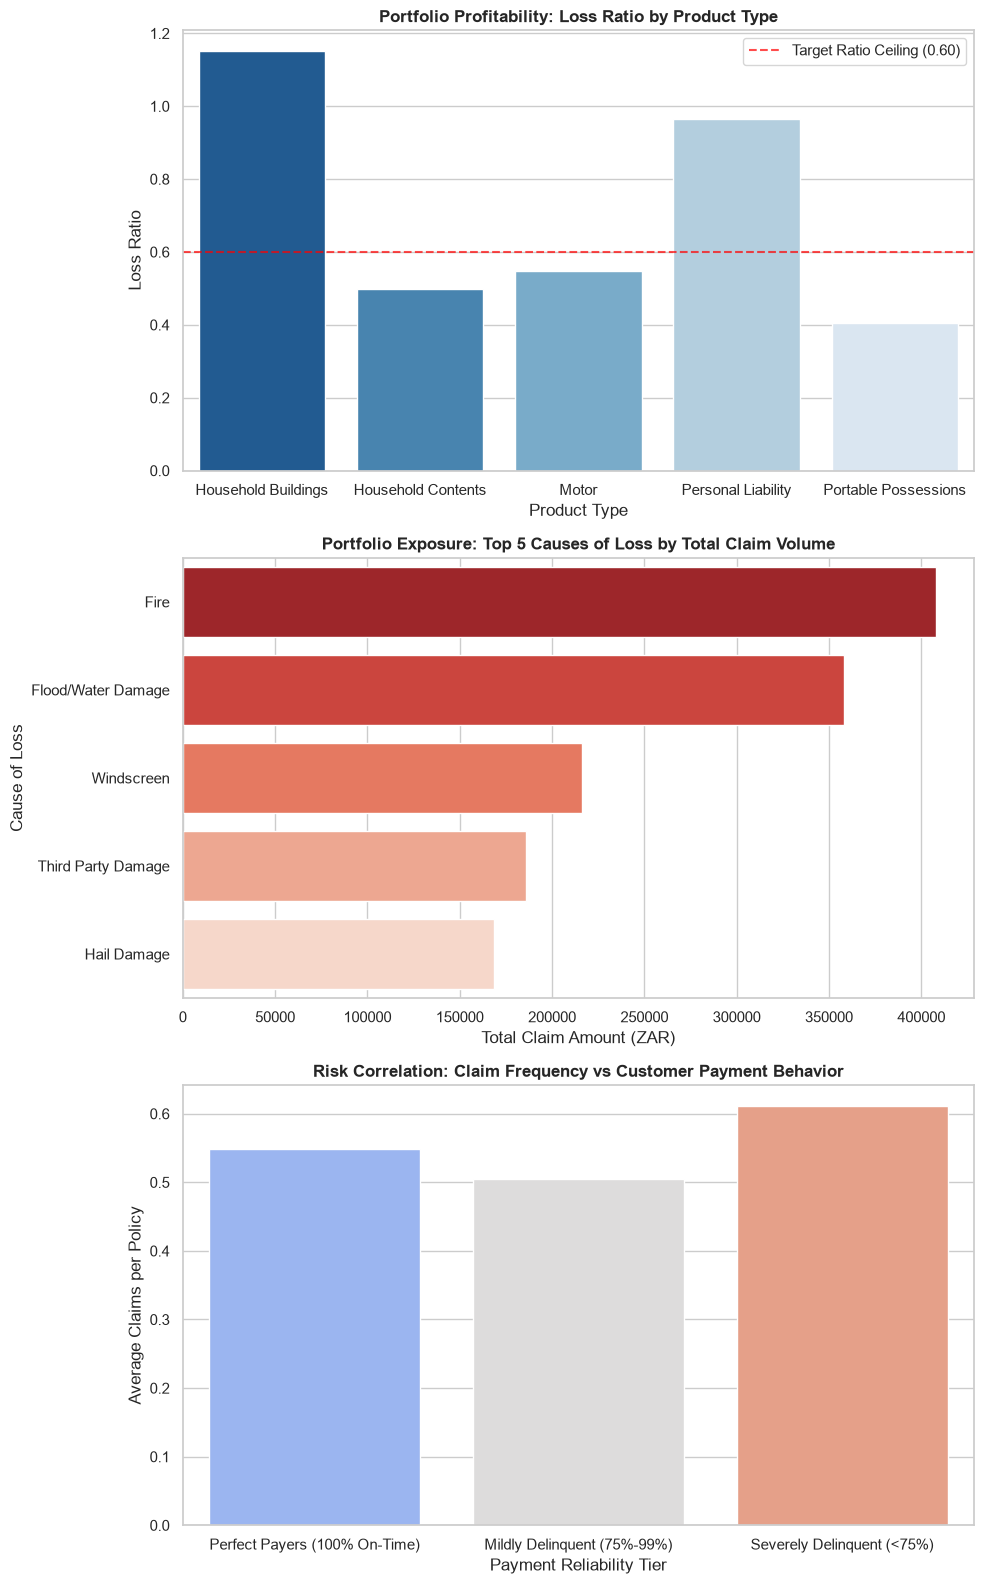

In [14]:
# B5 Visualizing the data from B3-B4

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic style for the charts
sns.set_theme(style="whitegrid")

# Create a layout with 3 distinct charts stacked vertically
fig, axes = plt.subplots(3, 1, figsize=(10, 16))

# --- CHART 1: Loss Ratio by Product Type (From B3a) ---
# We use the df_loss_ratio dataframe you created in Task B3
sns.barplot(
    data=df_loss_ratio, 
    x='product_type', 
    y='Loss Ratio', 
    ax=axes[0], 
    palette='Blues_r'
)
axes[0].set_title('Portfolio Profitability: Loss Ratio by Product Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Product Type')
axes[0].set_ylabel('Loss Ratio')
# Add a red dashed baseline at 0.60 (a typical target loss ratio ceiling)
axes[0].axhline(0.60, color='red', linestyle='--', alpha=0.7, label='Target Ratio Ceiling (0.60)')
axes[0].legend()

# --- CHART 2: Top 5 Causes of Loss by Amount (From B3c) ---
# We use the top_loss_causes dataframe from Task B3
sns.barplot(
    data=top_loss_causes, 
    x='claim_amount', 
    y='cause_of_loss', 
    ax=axes[1], 
    palette='Reds_r'
)
axes[1].set_title('Portfolio Exposure: Top 5 Causes of Loss by Total Claim Volume', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Claim Amount (ZAR)')
axes[1].set_ylabel('Cause of Loss')

# --- CHART 3: Claim Frequency by Payment Tier (From B4) ---
# Filter out the "No Payment History" group so it doesn't skew our visual trend
df_visual_risk = risk_correlation_matrix[risk_correlation_matrix['payment_tier'] != 'No Payment History'].copy()

sns.barplot(
    data=df_visual_risk, 
    x='payment_tier', 
    y='avg_claim_frequency', 
    ax=axes[2], 
    palette='coolwarm',
    order=['Perfect Payers (100% On-Time)', 'Mildly Delinquent (75%-99%)', 'Severely Delinquent (<75%)']
)
axes[2].set_title('Risk Correlation: Claim Frequency vs Customer Payment Behavior', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Payment Reliability Tier')
axes[2].set_ylabel('Average Claims per Policy')

# Adjust layout spacings cleanly so labels don't overlap
plt.tight_layout()
plt.show()


In [15]:
# B6 Risk Segmantation

print("=========================================================")
print("PART B6: STRATEGIC RISK SEGMENTATION MODEL")
print("=========================================================\n")

# Clean copy of working behavioral data frame
df_segments = df_behaviour_analysis.copy()

# Logical rules to place policies into risk tiers
def determine_risk_tier(row):
    # Calculate an individual policy's approximate loss ratio
    # If premium is 0 or NaN, default ratio to 0 to prevent division errors
    annual_prem = row['premium_monthly'] * 12
    policy_loss_ratio = row['total_paid_amt'] / annual_prem if annual_prem > 0 else 0
    
    # High financial claims risk + bad payment behavior
    if policy_loss_ratio > 0.80 or row['on_time_rate'] < 0.75:
        return 'Tier 1: High Risk (Action Required)'
    
    # Moderate claim loss ratio or minor payment hiccups
    elif (0.50 <= policy_loss_ratio <= 0.80) or (0.75 <= row['on_time_rate'] < 1.0):
        return 'Tier 2: Medium Risk (Monitor/Review)'
    
    # Low claims history + 100% perfect payment records
    else:
        return 'Tier 3: Low Risk (Preferred Book)'

# Apply the tier rules to every policy record
df_segments['risk_tier'] = df_segments.apply(determine_risk_tier, axis=1)

# Group and aggregate metrics to see what each tier means financially for BuddyCentral
segmentation_summary = df_segments.groupby('risk_tier').agg(
    total_policies=('policy_id', 'count'),
    combined_annual_premium=('premium_monthly', lambda x: (x * 12).sum()),
    combined_claims_paid=('total_paid_amt', 'sum')
).reset_index()

# Calculate the actual aggregate loss ratio per tier to validate our rules
segmentation_summary['tier_loss_ratio'] = segmentation_summary['combined_claims_paid'] / segmentation_summary['combined_annual_premium']

print("--- Corporate Risk Tiering Analysis Matrix ---")
display(segmentation_summary)


PART B6: STRATEGIC RISK SEGMENTATION MODEL

--- Corporate Risk Tiering Analysis Matrix ---


,risk_tier,total_policies,combined_annual_premium,combined_claims_paid,tier_loss_ratio
0,Tier 1: High Risk (Action Required),186,615950.52,1807744.17,2.934885
1,Tier 2: Medium Risk (Monitor/Review),381,1359765.36,68390.22,0.050296
2,Tier 3: Low Risk (Preferred Book),180,724019.04,12320.63,0.017017
